In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
import scarf

scarf.configure_output(level="ERROR", progress=False)
datasets = scarf.cytebase.connect("scarf_docs")
outputs = TemporaryDirectory()
output_dir = Path(outputs.name)
output_dir

PosixPath('/var/folders/v3/4132lx197d702pl_10s5r8b80000gn/T/tmp9q35dxm3')

In [2]:
mtx_dir = datasets.download_dataset(
    name="xin_1K_pancreas_rnaseq",
    destination=output_dir,
)
mtx_dir

Downloading bucket files: 54544298 / 54544298 complete

Downloading bytes: 54544298 / 54544298 complete

PosixPath('/var/folders/v3/4132lx197d702pl_10s5r8b80000gn/T/tmp9q35dxm3/xin_1K_pancreas_rnaseq')

In [3]:
candidates = scarf.inspect_mtx(str(mtx_dir))
pd.DataFrame(
    {
        index: {
            "matrix file": str(Path(candidate.matrixPath).relative_to(mtx_dir)),
            "feature file": str(Path(candidate.featurePath).relative_to(mtx_dir)),
            "cell file": str(Path(candidate.cellPath).relative_to(mtx_dir)),
            "orientation": candidate.matrixOrientation,
            "cells": candidate.nCells,
            "features": candidate.nFeatures,
            "stored entries": candidate.nEntries,
        }
        for index, candidate in enumerate(candidates)
    }
).rename_axis(columns="candidate")

candidate,0
matrix file,matrix.mtx.gz
feature file,features.tsv.gz
cell file,barcodes.tsv.gz
orientation,featuresByCells
cells,1600
features,39846
stored entries,9160987


In [4]:
mtx_store = output_dir / "xin_1K.zarr"
reader = scarf.MtxReader(candidates[0])
scarf.MtxToZarr(reader, zarr_loc=str(mtx_store)).dump()
mtx_store

PosixPath('/var/folders/v3/4132lx197d702pl_10s5r8b80000gn/T/tmp9q35dxm3/xin_1K.zarr')

In [5]:
ds_mtx = scarf.DataStore(str(mtx_store))
ds_mtx

DataStore has 1600 (1600) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentRibo'
   RNA assay has 39846 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'nCells'

In [6]:
h5ad_dir = datasets.download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination=output_dir,
)
h5ad_path = str(h5ad_dir / "data.h5ad")
inspection = scarf.inspect_h5ad(h5ad_path)
pd.Series(
    {
        "selected matrix": inspection.matrixKey,
        "available matrices": ", ".join(inspection.matrixCandidates),
        "encoding": inspection.matrixEncoding,
        "integer-like counts": inspection.integerLike,
        "cells": inspection.nCells,
        "features": inspection.nFeatures,
        "cell metadata": inspection.cellAttrsKey,
        "feature metadata": inspection.featureAttrsKey,
        "feature names": inspection.featureNameKey,
    },
    name="value",
).to_frame()

Downloading bucket files: 52477898 / 52477898 complete

Downloading bytes: 52477898 / 52477898 complete

,value
selected matrix,X
available matrices,"X, layers/spliced, layers/unspliced"
encoding,csr
integer-like counts,True
cells,3696
features,27998
cell metadata,obs
feature metadata,var
feature names,index


In [7]:
reader = scarf.H5adReader.from_inspect(
    inspection,
    embedding_roles={"X_umap": "umap"},
    cluster_keys=("clusters",),
)

pancreas_store = output_dir / "differentiating_pancreatic_cells.zarr"
h5ad_import = scarf.H5adToZarr(
    reader,
    zarr_loc=str(pancreas_store),
    analysis_assay="RNA",
).dump()
{
    "embeddings": dict(h5ad_import.embeddingArtifacts),
    "clusters": dict(h5ad_import.clusterArtifacts),
}

{'embeddings': {'X_umap': ArtifactRef(assay='RNA', kind='embedding', artifact_id='4308ca2b9e95...')},
 'clusters': {'clusters': ArtifactRef(assay='RNA', kind='cluster_labels', artifact_id='56f97bfc171c...')}}

In [8]:
from scarf.storage.count_matrix import CountMatrixPolicy

tenx_h5 = datasets.download_dataset(
    name="tenx_10K_pbmc-v1_atacseq",
    destination=output_dir,
)
atac_store = output_dir / "pbmc_atac.zarr"
reader = scarf.CrH5Reader(str(tenx_h5 / "data.h5"))
scarf.CrToZarr(
    reader,
    zarr_loc=str(atac_store),
    mem_budget="8G",
    policy=CountMatrixPolicy(unitBytes=500_000_000, chunkBytes=50_000_000),
).dump()
atac_store

Downloading bucket files: 79995014 / 79995014 complete

Downloading bytes: 79995014 / 79995014 complete

PosixPath('/var/folders/v3/4132lx197d702pl_10s5r8b80000gn/T/tmp9q35dxm3/pbmc_atac.zarr')

In [9]:
ds_atac = scarf.DataStore(str(atac_store))
ds_atac

DataStore has 8728 (8728) cells with 1 assays: ATAC
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_nCounts', 'ATAC_nFeatures'
   ATAC assay has 89796 features and following metadata:
            'I', 'ids', 'names', 'derivation', 'dropOuts', 
            'feature_type', 'genome', 'nCells'

In [10]:
ds = scarf.DataStore(str(pancreas_store))

imported_umap = np.asarray(
    ds.load_artifact(h5ad_import.embeddingArtifacts["X_umap"])["values"][:]
)
imported_clusters = np.asarray(
    ds.load_artifact(h5ad_import.clusterArtifacts["clusters"])["values"][:]
)
imported_umap.shape, imported_clusters.shape

((3696, 2), (3696,))

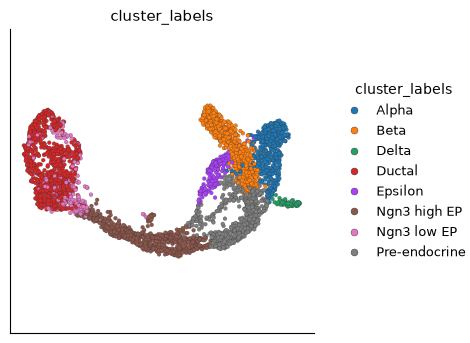

In [11]:
ds.plots.embedding(
    layout=h5ad_import.embeddingArtifacts["X_umap"],
    color_by=h5ad_import.clusterArtifacts["clusters"],
)

In [12]:
mtx_export = output_dir / "diff_pancreas"
scarf.writers.to_mtx(assay=ds.RNA, mtx_directory=str(mtx_export))
[(path.name, path.stat().st_size) for path in sorted(mtx_export.iterdir())]

[('barcodes.tsv', 62832), ('genes.tsv', 417116), ('matrix.mtx', 114507258)]

In [13]:
adata = ds.to_anndata(from_assay="RNA")
adata.obsm["X_umap"] = imported_umap
adata.obs["clusters"] = imported_clusters
h5ad_export = output_dir / "diff_pancreas.h5ad"
adata.write_h5ad(h5ad_export)
{"file": h5ad_export.name, "bytes": h5ad_export.stat().st_size}

{'file': 'diff_pancreas.h5ad', 'bytes': 59304360}

In [14]:
import anndata as ad

adata = ad.read_h5ad(h5ad_export)
sorted(adata.obsm.keys()), adata.obsm["X_umap"].shape

(['X_umap'], (3696, 2))

In [15]:
all_names = ds.RNA.feats.fetch_all("names").astype(str)
name_lookup = {name.upper(): name for name in all_names}
panel = [name_lookup[gene] for gene in ("GCG", "SST", "KRT19")]
selected = ds.to_anndata(from_assay="RNA", matrix="raw", feature_names=panel)
{
    "shape": selected.shape,
    "genes": selected.var["names"].tolist(),
}

{'shape': (3696, 3), 'genes': ['Gcg', 'Sst', 'Krt19']}

In [16]:
csv_path = output_dir / "toy_counts.csv"
csv_path.write_text(
    "quality,geneA,geneB,geneC\n"
    "10,1,0,2\n"
    "20,0,3,0\n"
    "30,4,5,6\n"
    "40,7,0,8\n"
    "50,9,10,0\n",
    encoding="utf-8",
)

print(csv_path.read_text(encoding="utf-8"))

quality,geneA,geneB,geneC
10,1,0,2
20,0,3,0
30,4,5,6
40,7,0,8
50,9,10,0



In [17]:
csv_zarr = output_dir / "toy_csv.zarr"
reader = scarf.CSVReader(
    str(csv_path),
    cell_data_cols=["quality"],
)
scarf.CSVtoZarr(reader, zarr_loc=str(csv_zarr), assay_name="RNA").dump()
ds_csv = scarf.DataStore(str(csv_zarr))
ds_csv.cells.head()

,I,ids,names,RNA_nCounts,RNA_nFeatures,quality
0,True,cell_0,cell_0,3.0,2.0,10
1,True,cell_1,cell_1,3.0,1.0,20
2,True,cell_2,cell_2,15.0,3.0,30
3,True,cell_3,cell_3,15.0,2.0,40
4,True,cell_4,cell_4,19.0,2.0,50


In [18]:
from scipy.sparse import csr_matrix

mat = csr_matrix(
    (
        [1, 10, 15, 10, 20, 2, 3, 1, 5],
        ([0, 0, 0, 1, 1, 1, 2, 2, 2], [1, 3, 8, 2, 3, 1, 2, 8, 9]),
    ),
    shape=(3, 10),
)
mat.toarray()

array([[ 0,  1,  0, 10,  0,  0,  0,  0, 15,  0],
       [ 0,  2, 10, 20,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  3,  0,  0,  0,  0,  0,  1,  5]])

In [19]:
sparse_zarr = output_dir / "toy_sparse.zarr"
scarf.SparseToZarr(
    mat,
    zarr_loc=str(sparse_zarr),
    cell_ids=[f"cell_{i}" for i in range(mat.shape[0])],
    feature_ids=[f"feat_{i}" for i in range(mat.shape[1])],
    assay_name="RNA",
).dump()
ds_sparse = scarf.DataStore(str(sparse_zarr))
ds_sparse

DataStore has 3 (3) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures'
   RNA assay has 10 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'